In [2]:
import geopandas as gpd
import pandas as pd
from blocksnet.config import log_config

log_config.set_logger_level('WARNING')

In [3]:
blocks = pd.read_pickle('../data/prostor/scenario/blocks_scenario_198.pickle')

In [ ]:
# ==== 0. Импорты ====
import pandas as pd
import numpy as np
import geopandas as gpd
from libpysal.weights import DistanceBand, lag_spatial
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

# ==== 1. Входные данные ====
# blocks = gpd.read_file("blocks.geojson")  # если нужно загрузить
# Укажи свои списки признаков:
orig_feats = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility'
]
cat_feats = ['land_use', 'morphotype']
numeric_feats = [c for c in orig_feats if c not in cat_feats]
radius_list = [300, 500, 1000, 2000, 3000]

# ==== 2. Модель ====
model = CatBoostRegressor()
model.load_model("../data/prostor/model.cbm")  # .cbm обучен на лог-цене

# ==== 3. Весовые матрицы по радиусам ====
w_radii = {}
for r in radius_list:
    w = DistanceBand.from_dataframe(
        blocks, threshold=r, binary=True, silence_warnings=True
    )
    w.transform = 'r'  # row-standardized
    w_radii[r] = w

# ==== 4. Функция лагов ====
def add_lags(frame: pd.DataFrame, numeric_feats, w_radii):
    f = frame.copy()
    gm = f[numeric_feats].mean()
    lag_cols = []
    for feat in numeric_feats:
        vec = f[feat].fillna(gm[feat])
        for r, w in w_radii.items():
            col = f'lag{r}_{feat}'
            f[col] = lag_spatial(w, vec)
            lag_cols.append(col)
    for r, w in w_radii.items():
        ncol = f'n_neighbors_{r}'
        f[ncol] = pd.Series({i: len(nb) for i, nb in w.neighbors.items()})
        lag_cols.append(ncol)
    return f, lag_cols

# ==== 5. Подготовка фичей и предсказание ====
blocks_with_lags, lag_cols = add_lags(blocks, numeric_feats, w_radii)
all_feats = orig_feats + lag_cols

X = blocks_with_lags[all_feats].copy()
for c in cat_feats:
    if c in X.columns:
        X[c] = X[c].fillna('missing').astype('category')

y_log = model.predict(X)                    # лог-цена
blocks_pred = blocks_with_lags.copy()
blocks_pred['y_log_pred'] = y_log
blocks_pred['price_pred'] = np.exp(y_log)   # цена





/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

Суммарная стоимость:
 • Сценические кварталы: 153 976 062 250 ₽
 • Контекст: 0 ₽
 • Все кварталы: 153 976 062 250 ₽


/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_12229/1692443492.py:60: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  context_6km.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2, zorder=1)


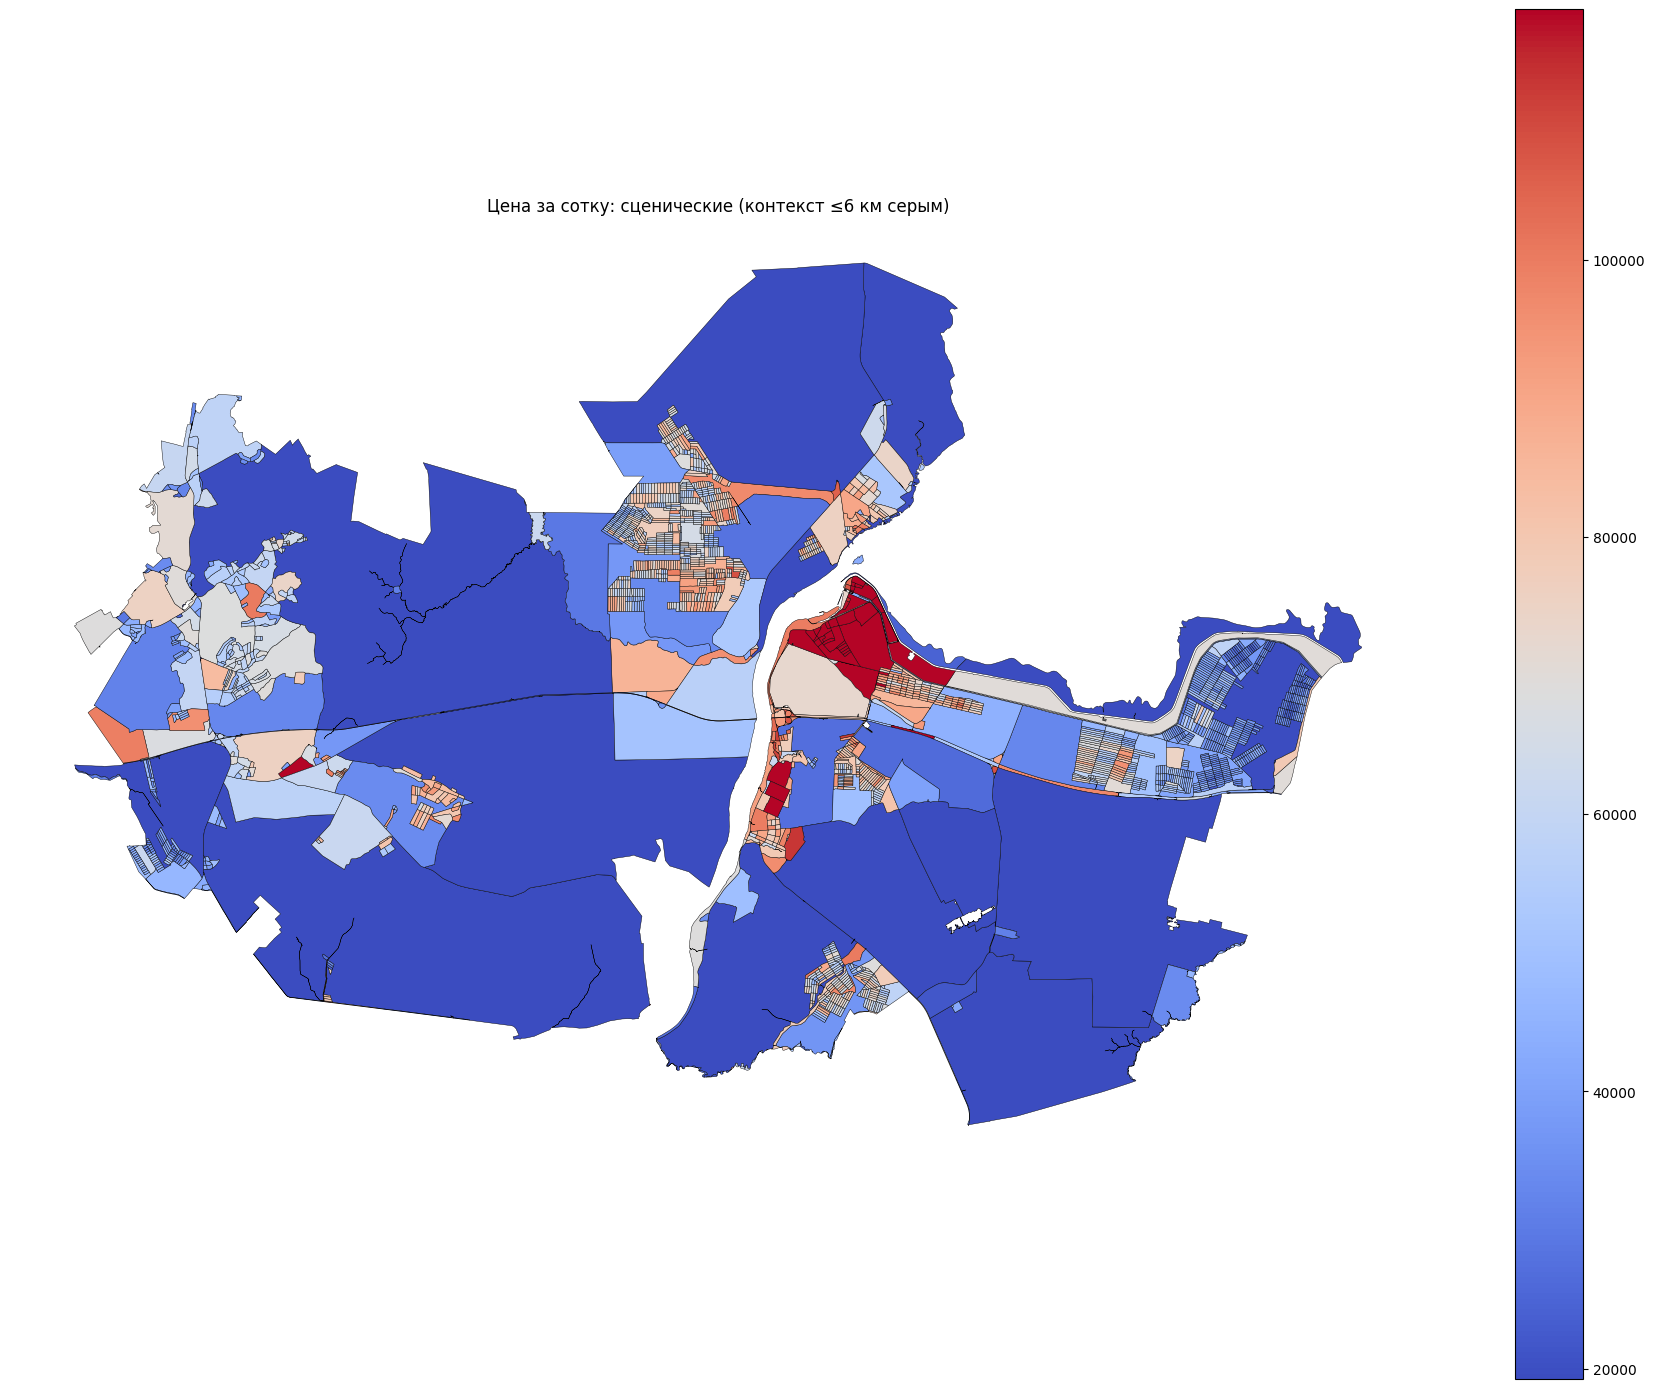

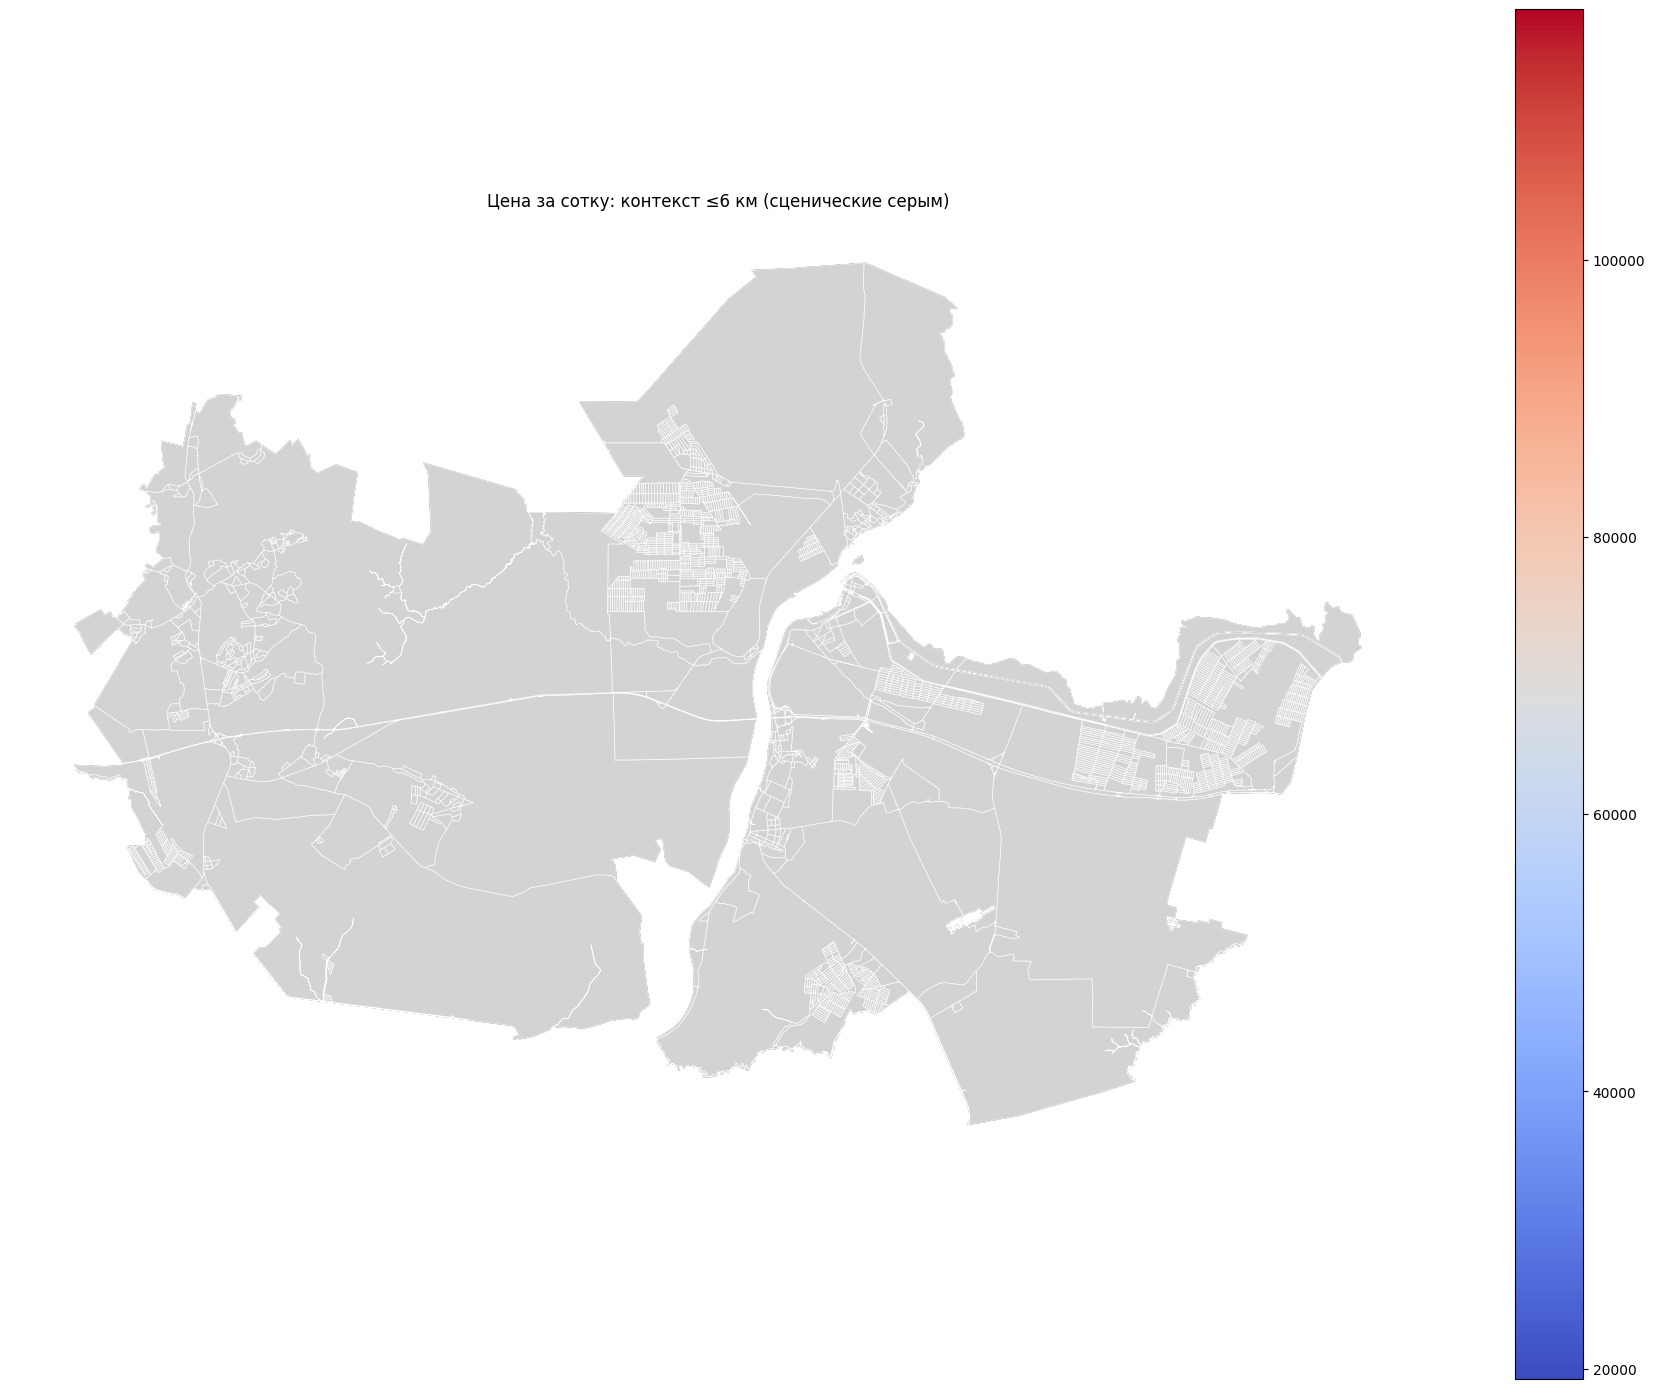

In [6]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

scenario = blocks.copy()  # сценарий 

# 0) цена и цена за сотку
if 'price_pred' not in blocks_pred.columns and 'y_log_pred' in blocks_pred.columns:
    blocks_pred['price_pred'] = np.exp(blocks_pred['y_log_pred'])
a = blocks_pred['site_area'].astype(float)
blocks_pred['price_per_sotka'] = np.where(a > 0, blocks_pred['price_pred'] / a * 100, np.nan)

# 1) CRS
if scenario.crs != blocks_pred.crs:
    scenario = scenario.to_crs(blocks_pred.crs)

# 2) флаг сценических (если нет)
if 'is_scn' not in blocks_pred.columns:
    sjoin_df = gpd.sjoin(
        blocks_pred[['geometry']].reset_index().rename(columns={'index':'_idx'}),
        scenario[['geometry']], how='inner', predicate='intersects'
    )
    scn_idx = sjoin_df['_idx'].unique()
    blocks_pred['is_scn'] = blocks_pred.index.isin(scn_idx)

scn = blocks_pred[blocks_pred['is_scn']].copy()
ctx = blocks_pred[~blocks_pred['is_scn']].copy()

# 3) буфер 6 км и отдельный gdf контекста
def make_buffer_m(gdf, radius_m):
    g = gpd.GeoDataFrame(geometry=[gdf.geometry.union_all()], crs=gdf.crs)
    if g.crs and g.crs.is_geographic:
        utm = g.estimate_utm_crs()
        g = g.to_crs(utm); g['geometry'] = g.buffer(radius_m); g = g.to_crs(blocks_pred.crs)
    else:
        g['geometry'] = g.buffer(radius_m)
    return g

buf6_gdf = make_buffer_m(scenario, 5000)
context_6km = gpd.clip(ctx, buf6_gdf)               # контекст, обрезанный буфером
# при желании оставить только попадающие целиком:
# context_6km = ctx[ctx.intersects(buf6_gdf.geometry.iloc[0])].copy()

# 4) статистика по ВСЕМ
total_scn = float(scn['price_pred'].sum())
total_ctx_all = float(ctx['price_pred'].sum())
total_all = float(blocks_pred['price_pred'].sum())

print("Суммарная стоимость:")
print(" • Сценические кварталы:", f"{total_scn:,.0f} ₽".replace(',', ' '))
print(" • Контекст:",             f"{total_ctx_all:,.0f} ₽".replace(',', ' '))
print(" • Все кварталы:",         f"{total_all:,.0f} ₽".replace(',', ' '))



# 5) карта: сценические (контекст = context_6km серым)
vmin1 = scn['price_per_sotka'].quantile(0.02) if len(scn) else blocks_pred['price_per_sotka'].min()
vmax1 = scn['price_per_sotka'].quantile(0.98) if len(scn) else blocks_pred['price_per_sotka'].max()
fig, ax = plt.subplots(figsize=(18, 14))
context_6km.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2, zorder=1)
scn.plot(ax=ax, column='price_per_sotka', cmap='coolwarm',
         vmin=vmin1, vmax=vmax1, legend=True,
         edgecolor='black', linewidth=0.3, zorder=2)
ax.set_title('Цена за сотку: сценические (контекст ≤6 км серым)'); ax.axis('off')
plt.tight_layout(); plt.show()

# 6) карта: контекст ≤6 км по цене за сотку, сценические серым
vmin2 = blocks_pred['price_per_sotka'].quantile(0.02) if len(blocks_pred) else blocks_pred['price_per_sotka'].min()
vmax2 = blocks_pred['price_per_sotka'].quantile(0.98) if len(blocks_pred) else blocks_pred['price_per_sotka'].max()

fig, ax = plt.subplots(figsize=(18, 14))
# контекст окрашиваем
if len(blocks_pred):
    blocks_pred.plot(
        ax=ax, column='price_per_sotka', cmap='coolwarm',
        vmin=vmin2, vmax=vmax2, legend=True,
        edgecolor='black', linewidth=0.3, zorder=1
    )
# сценические серым сверху
if len(scn):
    scn.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5, zorder=2)

ax.set_title('Цена за сотку: контекст ≤6 км (сценические серым)', pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()



In [ ]:
blocks_2 = blocks_pred

In [ ]:
blocks_1 = blocks_pred

In [ ]:
import geopandas as gpd
import numpy as np

# --- подготовка цены ---
def ensure_price(df):
    if 'price_pred' not in df.columns and 'y_log_pred' in df.columns:
        df = df.copy()
        df['price_pred'] = np.exp(df['y_log_pred'])
    return df

b1 = ensure_price(blocks_1)
b2 = ensure_price(blocks_2)

# --- сумма только контекста (is_scn == False) ---
sum_ctx_1 = float(b1.loc[~b1['is_scn'], 'price_pred'].sum())
sum_ctx_2 = float(b2.loc[~b2['is_scn'], 'price_pred'].sum())

diff_abs = sum_ctx_2 - sum_ctx_1
diff_pct = (sum_ctx_2 / sum_ctx_1 - 1.0) * 100 if sum_ctx_1 > 0 else np.nan

print("Стоимость контекста:")
print(" • В блокс_1:", f"{sum_ctx_1:,.0f} ₽".replace(',', ' '))
print(" • В блокс_2:", f"{sum_ctx_2:,.0f} ₽".replace(',', ' '))
print(" • Изменение:", f"{diff_abs:,.0f} ₽".replace(',', ' '), f"({diff_pct:+.2f}%)")


Стоимость контекста:
 • В блокс_1: 145 408 247 937 ₽
 • В блокс_2: 149 119 716 399 ₽
 • Изменение: 3 711 468 461 ₽ (+2.55%)


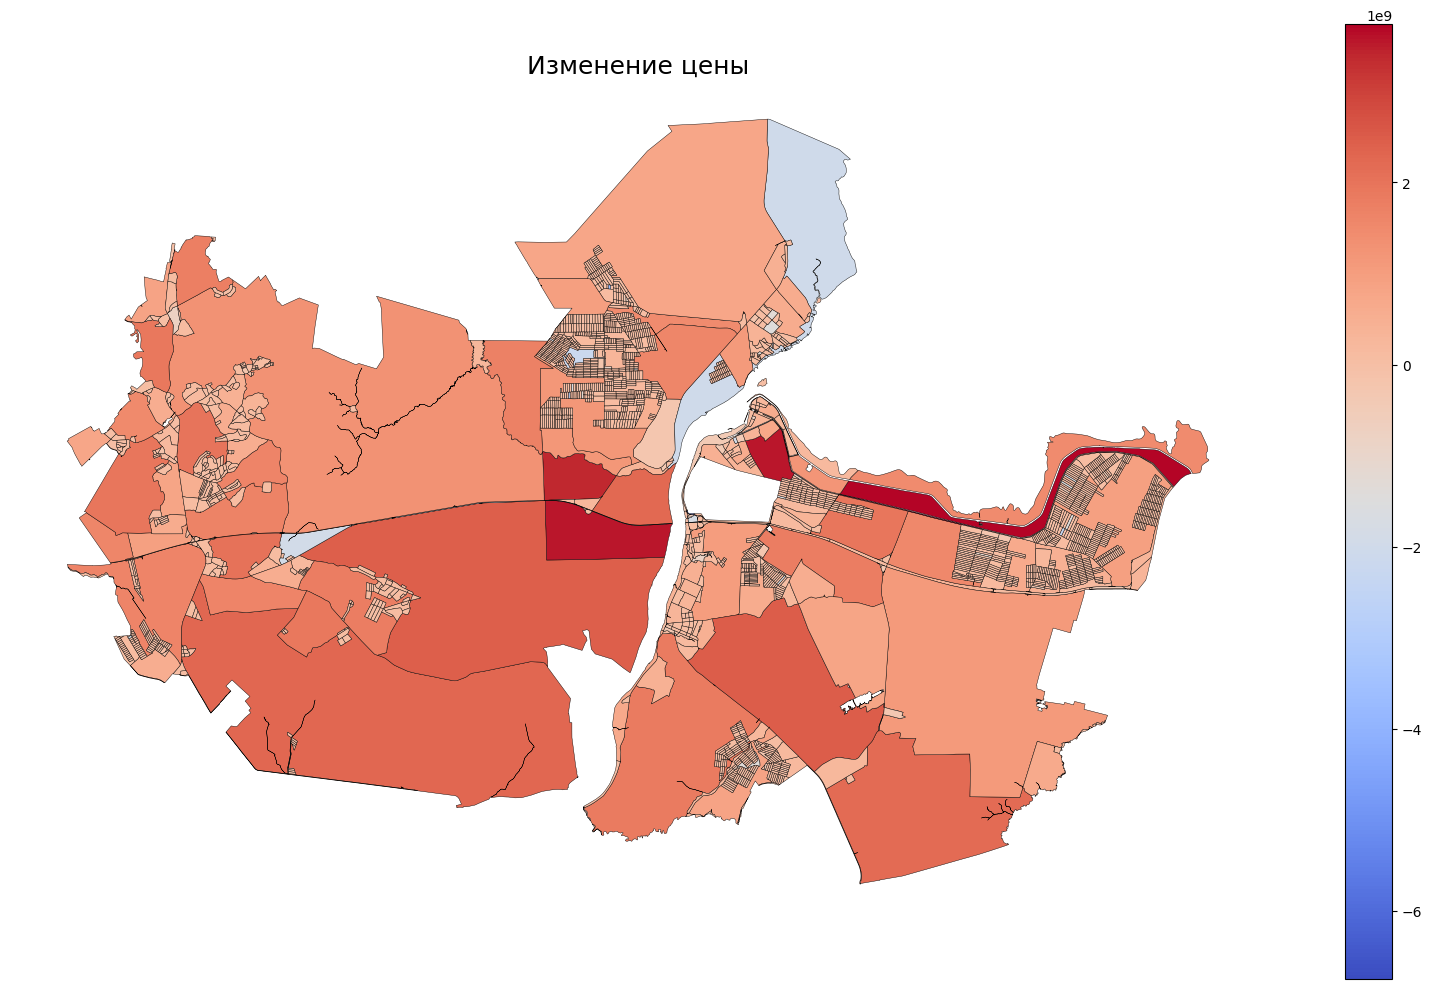

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# фильтрация только несценарных кварталов
base1 = blocks_1[~blocks_1["is_scn"]].copy()
base2 = blocks_2[~blocks_2["is_scn"]].copy()

# сортировка индекса
base1 = base1.sort_index()
base2 = base2.sort_index()

# изменение по соткам
diff = base1[["geometry"]].copy()
diff["delta_price_pred"] = base1["price_pred"] - base2["price_pred"]

# построение одной большой карты
fig, ax = plt.subplots(1, 1, figsize=(16, 10))

diff.plot(
    column="delta_price_pred",
    cmap="coolwarm",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

ax.set_axis_off()
ax.set_title("Изменение цены", fontsize=18)

plt.tight_layout()
plt.show()


/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

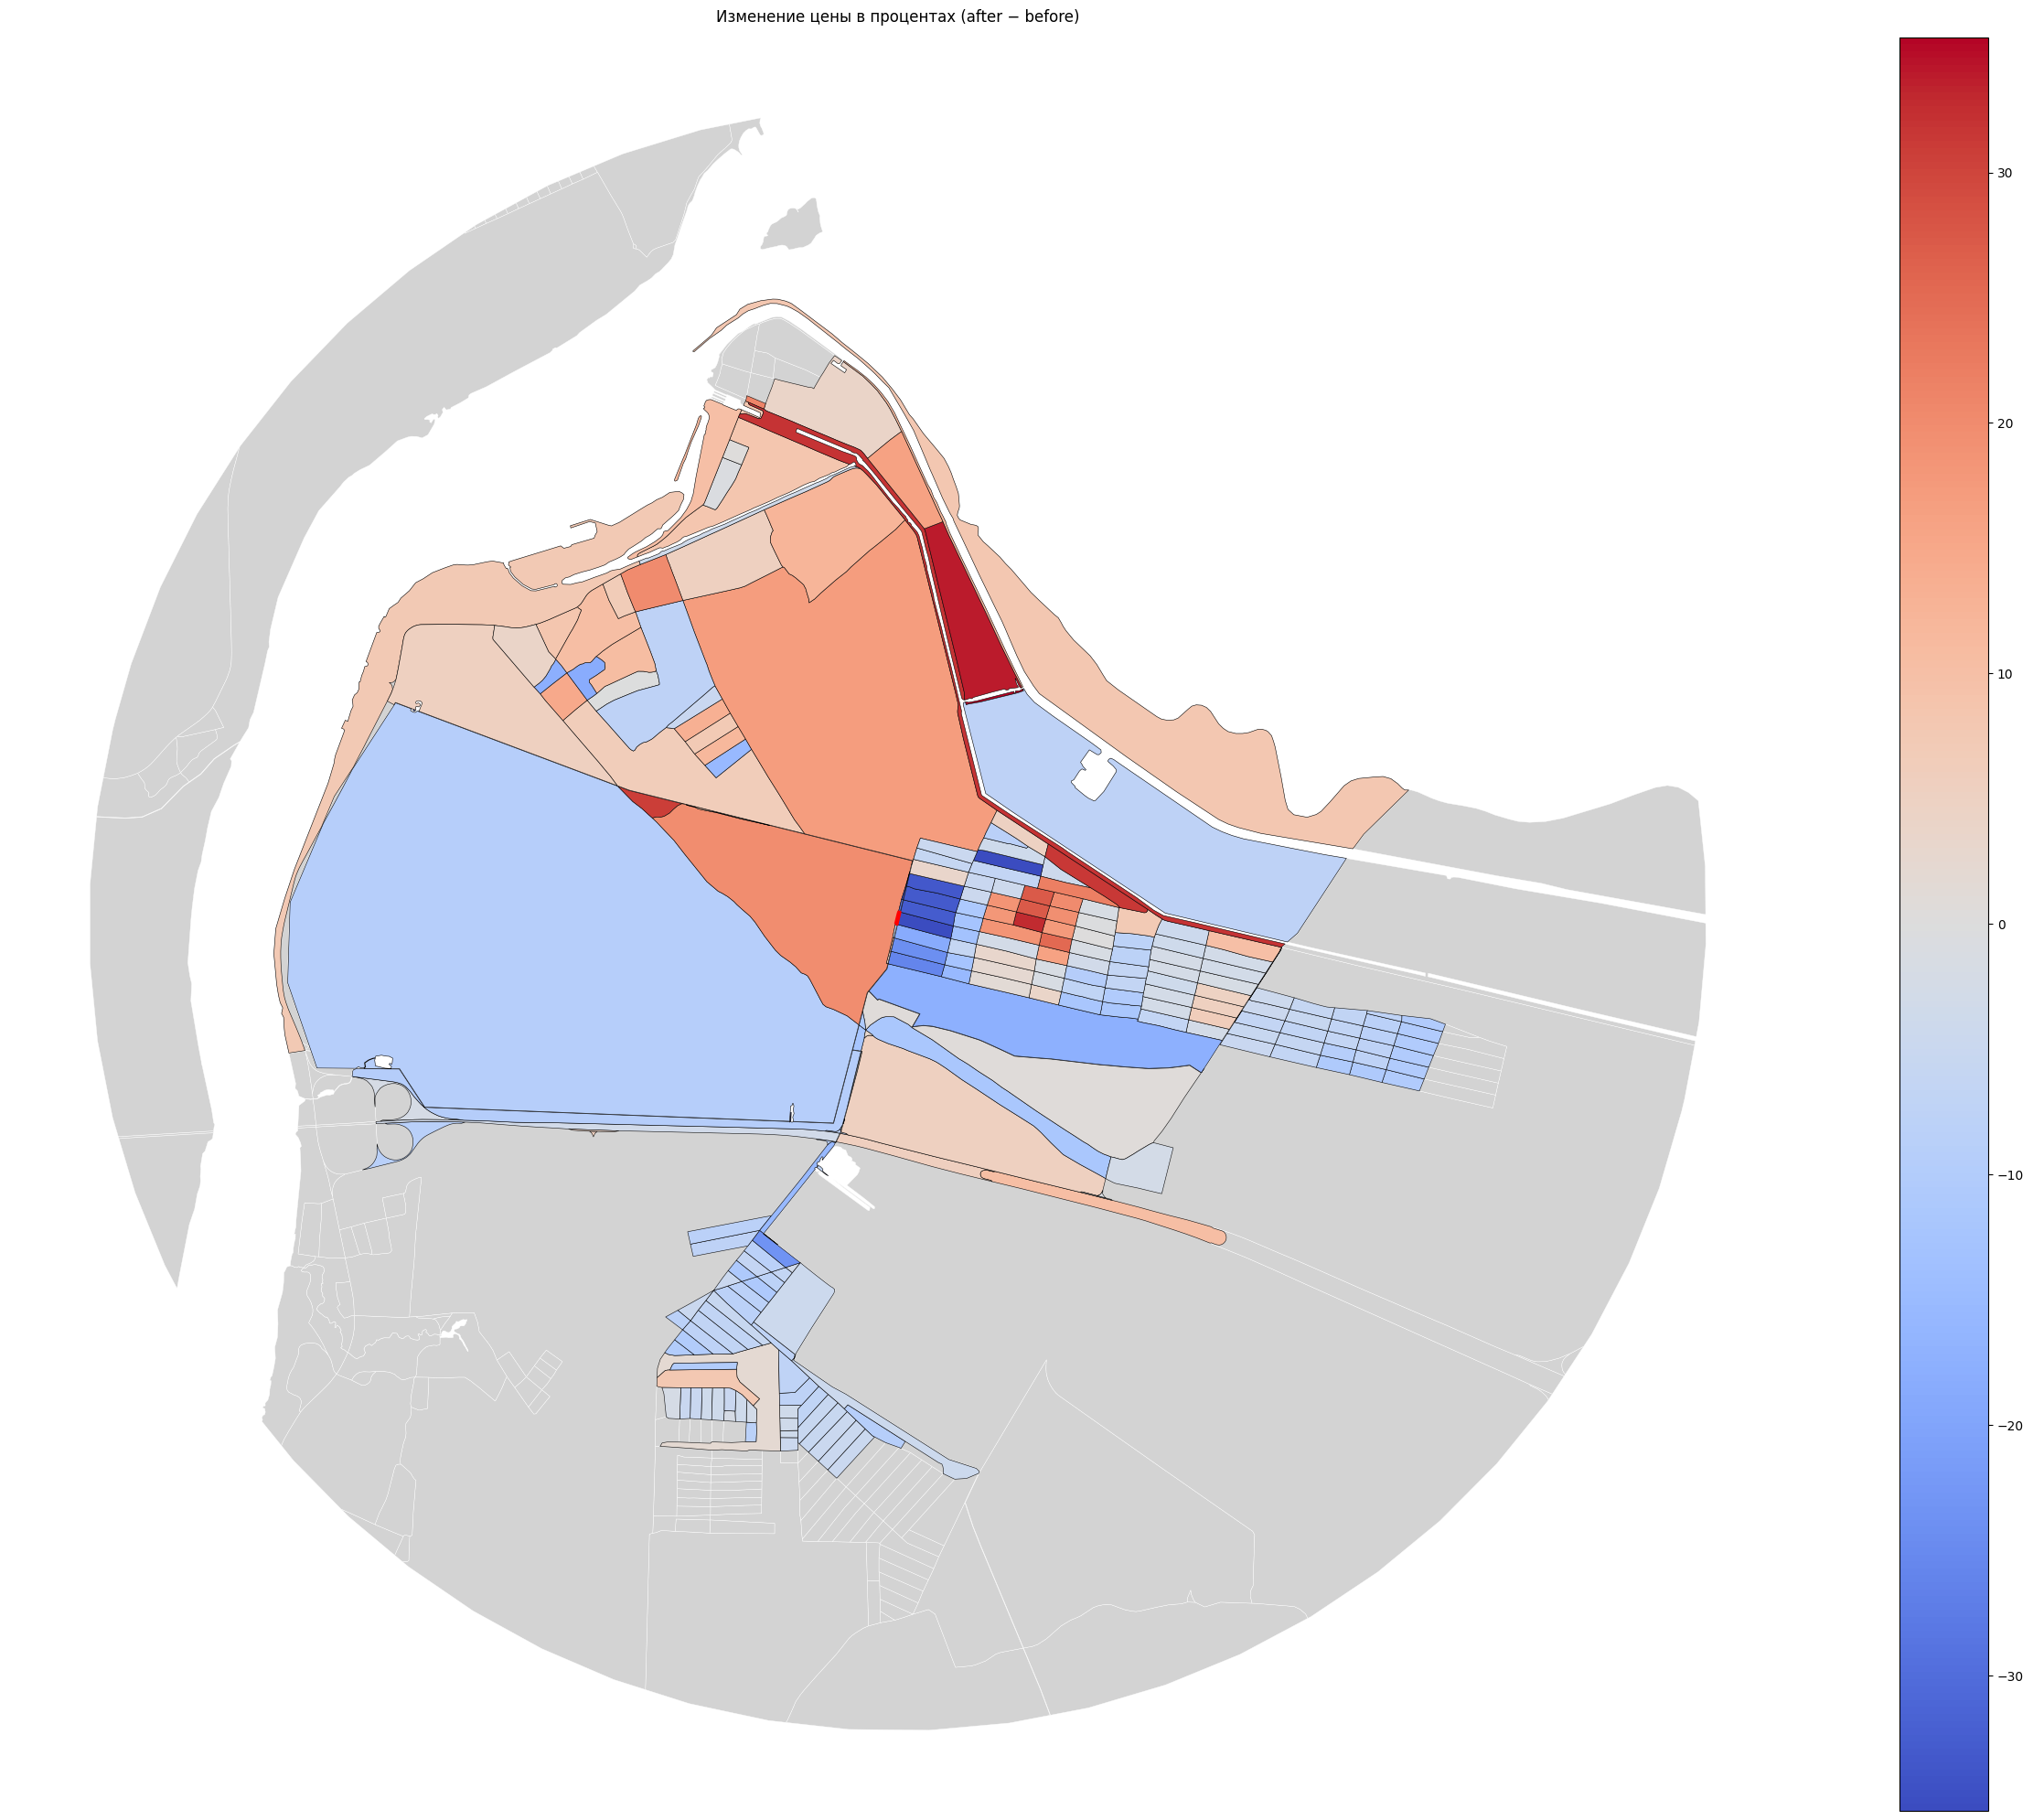


Статистика по кварталам в пределах 5 км:
index | до (₽) → после (₽) | Δ₽ | Δ%
388 | 799 658 357 ₽ → 799 658 357 ₽ | +0 ₽ | +0.0%
2495 | 628 860 ₽ → 628 860 ₽ | +0 ₽ | +0.0%
2496 | 555 897 966 ₽ → 555 897 966 ₽ | +0 ₽ | +0.0%
96 | 2 543 062 785 ₽ → 2 543 062 785 ₽ | +0 ₽ | +0.0%
1452 | 1 273 260 ₽ → 1 273 260 ₽ | +0 ₽ | +0.0%
1456 | 5 080 161 ₽ → 5 080 161 ₽ | +0 ₽ | +0.0%
1455 | 11 129 079 ₽ → 11 129 079 ₽ | +0 ₽ | +0.0%
977 | 608 073 877 ₽ → 608 073 877 ₽ | +0 ₽ | +0.0%
993 | 16 827 885 ₽ → 16 827 885 ₽ | +0 ₽ | +0.0%
69 | 14 564 732 ₽ → 14 564 732 ₽ | +0 ₽ | +0.0%
984 | 19 395 260 ₽ → 19 395 260 ₽ | +0 ₽ | +0.0%
991 | 11 649 527 ₽ → 11 649 527 ₽ | +0 ₽ | +0.0%
978 | 12 068 686 ₽ → 12 068 686 ₽ | +0 ₽ | +0.0%
1000 | 10 919 533 ₽ → 10 919 533 ₽ | +0 ₽ | +0.0%
990 | 4 903 705 ₽ → 4 903 705 ₽ | +0 ₽ | +0.0%
989 | 5 355 172 ₽ → 5 355 172 ₽ | +0 ₽ | +0.0%
1528 | 5 487 902 ₽ → 5 487 902 ₽ | +0 ₽ | +0.0%
1485 | 5 421 889 ₽ → 5 421 889 ₽ | +0 ₽ | +0.0%
1461 | 9 485 300 ₽ → 9 485 300 ₽ | +0 ₽

In [12]:
# ------------ 0. Импорты и константы ------------
import pandas as pd
import numpy as np
import geopandas as gpd
from catboost import CatBoostRegressor
from libpysal.weights import DistanceBand, lag_spatial
import matplotlib.pyplot as plt

orig_feats = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility'
]
cat_feats = ['land_use', 'morphotype']
numeric_feats = [c for c in orig_feats if c not in cat_feats]
radius_list = [300, 500, 1000, 2000, 3000]

# ------------ 1. Данные и модель ------------
# blocks: GeoDataFrame с исходными фичами и geometry
model = CatBoostRegressor()
model.load_model('../data/prostor/model.cbm')

# ------------ 2. Матрицы соседства ------------
w_radii = {}
for r in radius_list:
    w = DistanceBand.from_dataframe(blocks, threshold=r, binary=True, silence_warnings=True)
    w.transform = 'r'
    w_radii[r] = w

# ------------ 3. Применение сценария к одному кварталу ------------
def apply_scenario(blocks, target_idx: int, changes: dict) -> pd.DataFrame:
    df = blocks.copy()
    row = df.loc[target_idx].to_dict()
    row.update(changes)

    site_area = float(row['site_area'])

    build = float(row.get('build_floor_area', df.at[target_idx, 'build_floor_area']))
    live  = float(row.get('living_area',       df.at[target_idx, 'living_area']))
    non   = row.get('non_living_area', np.nan)

    if not np.isfinite(non):
        if 'build_floor_area' in changes and 'living_area' in changes:
            non = max(build - live, 0.0)
        elif ('mxi' in changes) or ('mxi' in row):
            mxi = float(row.get('mxi', df.at[target_idx, 'mxi']))
            non = max(mxi * build, 0.0)
        else:
            non = float(df.at[target_idx, 'non_living_area'])

    if ('non_living_area' in changes and 'living_area' in changes) and ('build_floor_area' not in changes):
        build = live + non

    row['build_floor_area'] = build
    row['living_area']      = live
    row['non_living_area']  = non

    footprint = float(row.get('footprint_area', df.at[target_idx, 'footprint_area']))
    pop       = float(row.get('population',     df.at[target_idx, 'population']))

    row['fsi']  = build / site_area if site_area > 0 else np.nan
    row['gsi']  = footprint / site_area if site_area > 0 else np.nan
    row['mxi']  = (non / build) if build > 0 else 0.0
    row['l']    = (build / pop) if pop > 0 else np.nan
    row['osr']  = (site_area - footprint) / site_area if site_area > 0 else np.nan
    row['share_living']     = live / site_area if site_area > 0 else np.nan
    row['share_non_living'] = non / site_area if site_area > 0 else np.nan

    if 'residential' in changes and 'share' not in changes:
        row['share'] = float(row['residential'])

    for k, v in row.items():
        df.at[target_idx, k] = v

    return df

# ------------ 4. Визуализация «до/после» в радиусе 5 км ------------
def plot_scenario_with_radii_from_blocks(
    blocks_before, blocks_after, w_radii, model,
    orig_feats, numeric_feats, target_idx, eps=1e-9
):
    import numpy as np
    import geopandas as gpd
    import matplotlib.pyplot as plt

    # — форматтеры —
    def fmt_rub(x, signed=False, digits=0):
        try:
            x = float(x)
            if not np.isfinite(x): return '—'
            s = f"{x:+,.{digits}f}" if signed else f"{x:,.{digits}f}"
            return s.replace(',', ' ') + " ₽"
        except Exception:
            return '—'

    def fmt_pct(x, digits=1):
        try:
            x = float(x)
            if not np.isfinite(x): return '—'
            return f"{x:+.{digits}f}%"
        except Exception:
            return '—'

    # — лаги по всему фрейму —
    radius_list = sorted(w_radii.keys())
    def add_lags(frame):
        f = frame.copy()
        gm = f[numeric_feats].mean()
        lag_cols = []
        for feat in numeric_feats:
            vec = f[feat].fillna(gm[feat])
            for r in radius_list:
                col = f'lag{r}_{feat}'
                f[col] = lag_spatial(w_radii[r], vec)
                lag_cols.append(col)
        for r in radius_list:
            ncol = f'n_neighbors_{r}'
            f[ncol] = pd.Series({i: len(nb) for i, nb in w_radii[r].neighbors.items()})
            lag_cols.append(ncol)
        return f, lag_cols

    b_with_lags, lag_cols = add_lags(blocks_before)
    a_with_lags, _        = add_lags(blocks_after)

    all_feats = orig_feats + lag_cols
    Xb = b_with_lags[all_feats].copy()
    Xa = a_with_lags[all_feats].copy()
    for X in (Xb, Xa):
        if 'land_use' in X:   X['land_use']   = X['land_use'].fillna('missing').astype('category')
        if 'morphotype' in X: X['morphotype'] = X['morphotype'].fillna('missing').astype('category')

    # — предсказания лог-цен и цены —
    log_before = model.predict(Xb)
    log_after  = model.predict(Xa)

    gdf_all = a_with_lags.copy()
    gdf_all['price_before'] = np.exp(log_before)
    gdf_all['price_after']  = np.exp(log_after)
    gdf_all['d_rub'] = gdf_all['price_after'] - gdf_all['price_before']
    gdf_all['d_pct'] = (gdf_all['price_after'] / gdf_all['price_before'] - 1.0) * 100

    # — буфер 5 км от целевого квартала —
    tgt_geom = blocks_before.loc[target_idx, 'geometry']
    buf = gpd.GeoSeries([tgt_geom], crs=blocks_before.crs)
    if buf.crs and buf.crs.is_geographic:
        utm = buf.estimate_utm_crs()
        buf = buf.to_crs(utm).buffer(4500).to_crs(blocks_before.crs)
    else:
        buf = buf.buffer(4500)
    buf_poly = gpd.GeoDataFrame(geometry=buf, crs=blocks_before.crs)

    gdf_map = gpd.clip(gdf_all, buf_poly)

    # — слои для карты —
    changed   = gdf_map[np.abs(gdf_map['d_rub'].astype(float)) > eps].copy()
    unchanged = gdf_map[np.abs(gdf_map['d_rub'].astype(float)) <= eps].copy()

    # — шкала —
    if len(changed):
        ql, qh = changed['d_pct'].quantile([0.02, 0.98]).astype(float)
        lim = float(max(abs(ql), abs(qh)))
        vmin, vmax = -lim, lim
    else:
        vmin, vmax = -1.0, 1.0

    # — карта —
    # --- карта: внутри 5 км; неизменные серым, изменённые по % ---
    fig, ax = plt.subplots(figsize=(25, 20))
    if len(unchanged):
        unchanged.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, zorder=1)
    if len(changed):
        changed.plot(ax=ax, column='d_pct', cmap='coolwarm',
                    vmin=vmin, vmax=vmax, legend=True,
                    edgecolor='black', linewidth=0.4, zorder=2)

    # рамка целевого
    gpd.GeoDataFrame(geometry=[blocks_before.loc[target_idx, 'geometry']], crs=blocks_before.crs) \
    .boundary.plot(ax=ax, edgecolor='red', linewidth=2.0, zorder=3)

    # # --- подписи: land_use и Δ% только для изменившихся кварталов ---
    # for _, row in changed.iterrows():
    #     x, y = row.geometry.representative_point().coords[0]
    #     lu = str(row.get('land_use', 'missing'))
    #     dp = row['d_pct']
    #     label = f"{lu}\n{dp:+.1f}%"
    #     ax.text(x, y, label, ha='center', va='center',  fontsize=7, zorder=4)

    ax.set_title('Изменение цены в процентах (after − before)', pad=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # — СТАТИСТИКА ПОСЛЕ КАРТЫ —
    # строка на территорию
    print("\nСтатистика по кварталам в пределах 5 км:")
    print("index | до (₽) → после (₽) | Δ₽ | Δ%")
    for i, row in gdf_map.iterrows():
        print(
            f"{i} | {fmt_rub(row['price_before'])} → {fmt_rub(row['price_after'])} | "
            f"{fmt_rub(row['d_rub'], signed=True)} | {fmt_pct(row['d_pct'])}"
        )

    # сводка
    sum_before = float(gdf_map['price_before'].sum())
    sum_after  = float(gdf_map['price_after'].sum())
    sum_d      = sum_after - sum_before
    sum_pct    = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

    print("\nСводка по буферу 5 км:")
    print(" • Сумма до:   ", fmt_rub(sum_before))
    print(" • Сумма после:", fmt_rub(sum_after))
    print(" • Изм., ₽:    ", fmt_rub(sum_d, signed=True))
    print(" • Изм., %:    ", fmt_pct(sum_pct))
    print(" • Территорий: ", len(gdf_map))


# ------------ 5. Вызов ------------
blocks_before = blocks
changes = {
    'land_use': 'RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
}
target_idx = 3
blocks_after = apply_scenario(blocks_before, target_idx, changes)

plot_scenario_with_radii_from_blocks(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    w_radii=w_radii,
    model=model,
    orig_feats=orig_feats,
    numeric_feats=numeric_feats,
    target_idx=target_idx
)


/Users/mvin/prostor-examples/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mvin/prostor-examples/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/Users/mvin/prostor-examples/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling

Δ цены в процентах (после − до):
 • 62 (target): 19.029 → 19.650 (Δ +0.620 log, +85.9%)
 • 0 (radius_1000m): 18.222 → 18.277 (Δ +0.055 log, +5.7%)
 • 1 (radius_1000m): 18.797 → 18.901 (Δ +0.104 log, +10.9%)
 • 2 (radius_1000m): 18.188 → 18.215 (Δ +0.026 log, +2.7%)
 • 3 (radius_1000m): 19.332 → 19.338 (Δ +0.006 log, +0.6%)
 • 6 (radius_1000m): 16.392 → 16.400 (Δ +0.009 log, +0.9%)
 • 8 (radius_1000m): 17.585 → 17.635 (Δ +0.051 log, +5.2%)
 • 9 (radius_1000m): 19.659 → 19.692 (Δ +0.033 log, +3.3%)
 • 34 (radius_1000m): 18.676 → 18.702 (Δ +0.026 log, +2.6%)
 • 36 (radius_1000m): 18.180 → 18.220 (Δ +0.040 log, +4.1%)
 • 60 (radius_1000m): 10.691 → 10.889 (Δ +0.197 log, +21.8%)
 • 61 (radius_1000m): 13.248 → 13.113 (Δ -0.135 log, -12.6%)
 • 68 (radius_1000m): 10.987 → 11.079 (Δ +0.092 log, +9.7%)
 • 80 (radius_1000m): 17.017 → 17.147 (Δ +0.130 log, +13.9%)
 • 567 (radius_1000m): 15.897 → 16.060 (Δ +0.162 log, +17.6%)
 • 4 (radius_2000m): 10.321 → 10.480 (Δ +0.159 log, +17.2%)
 • 5 (radius_

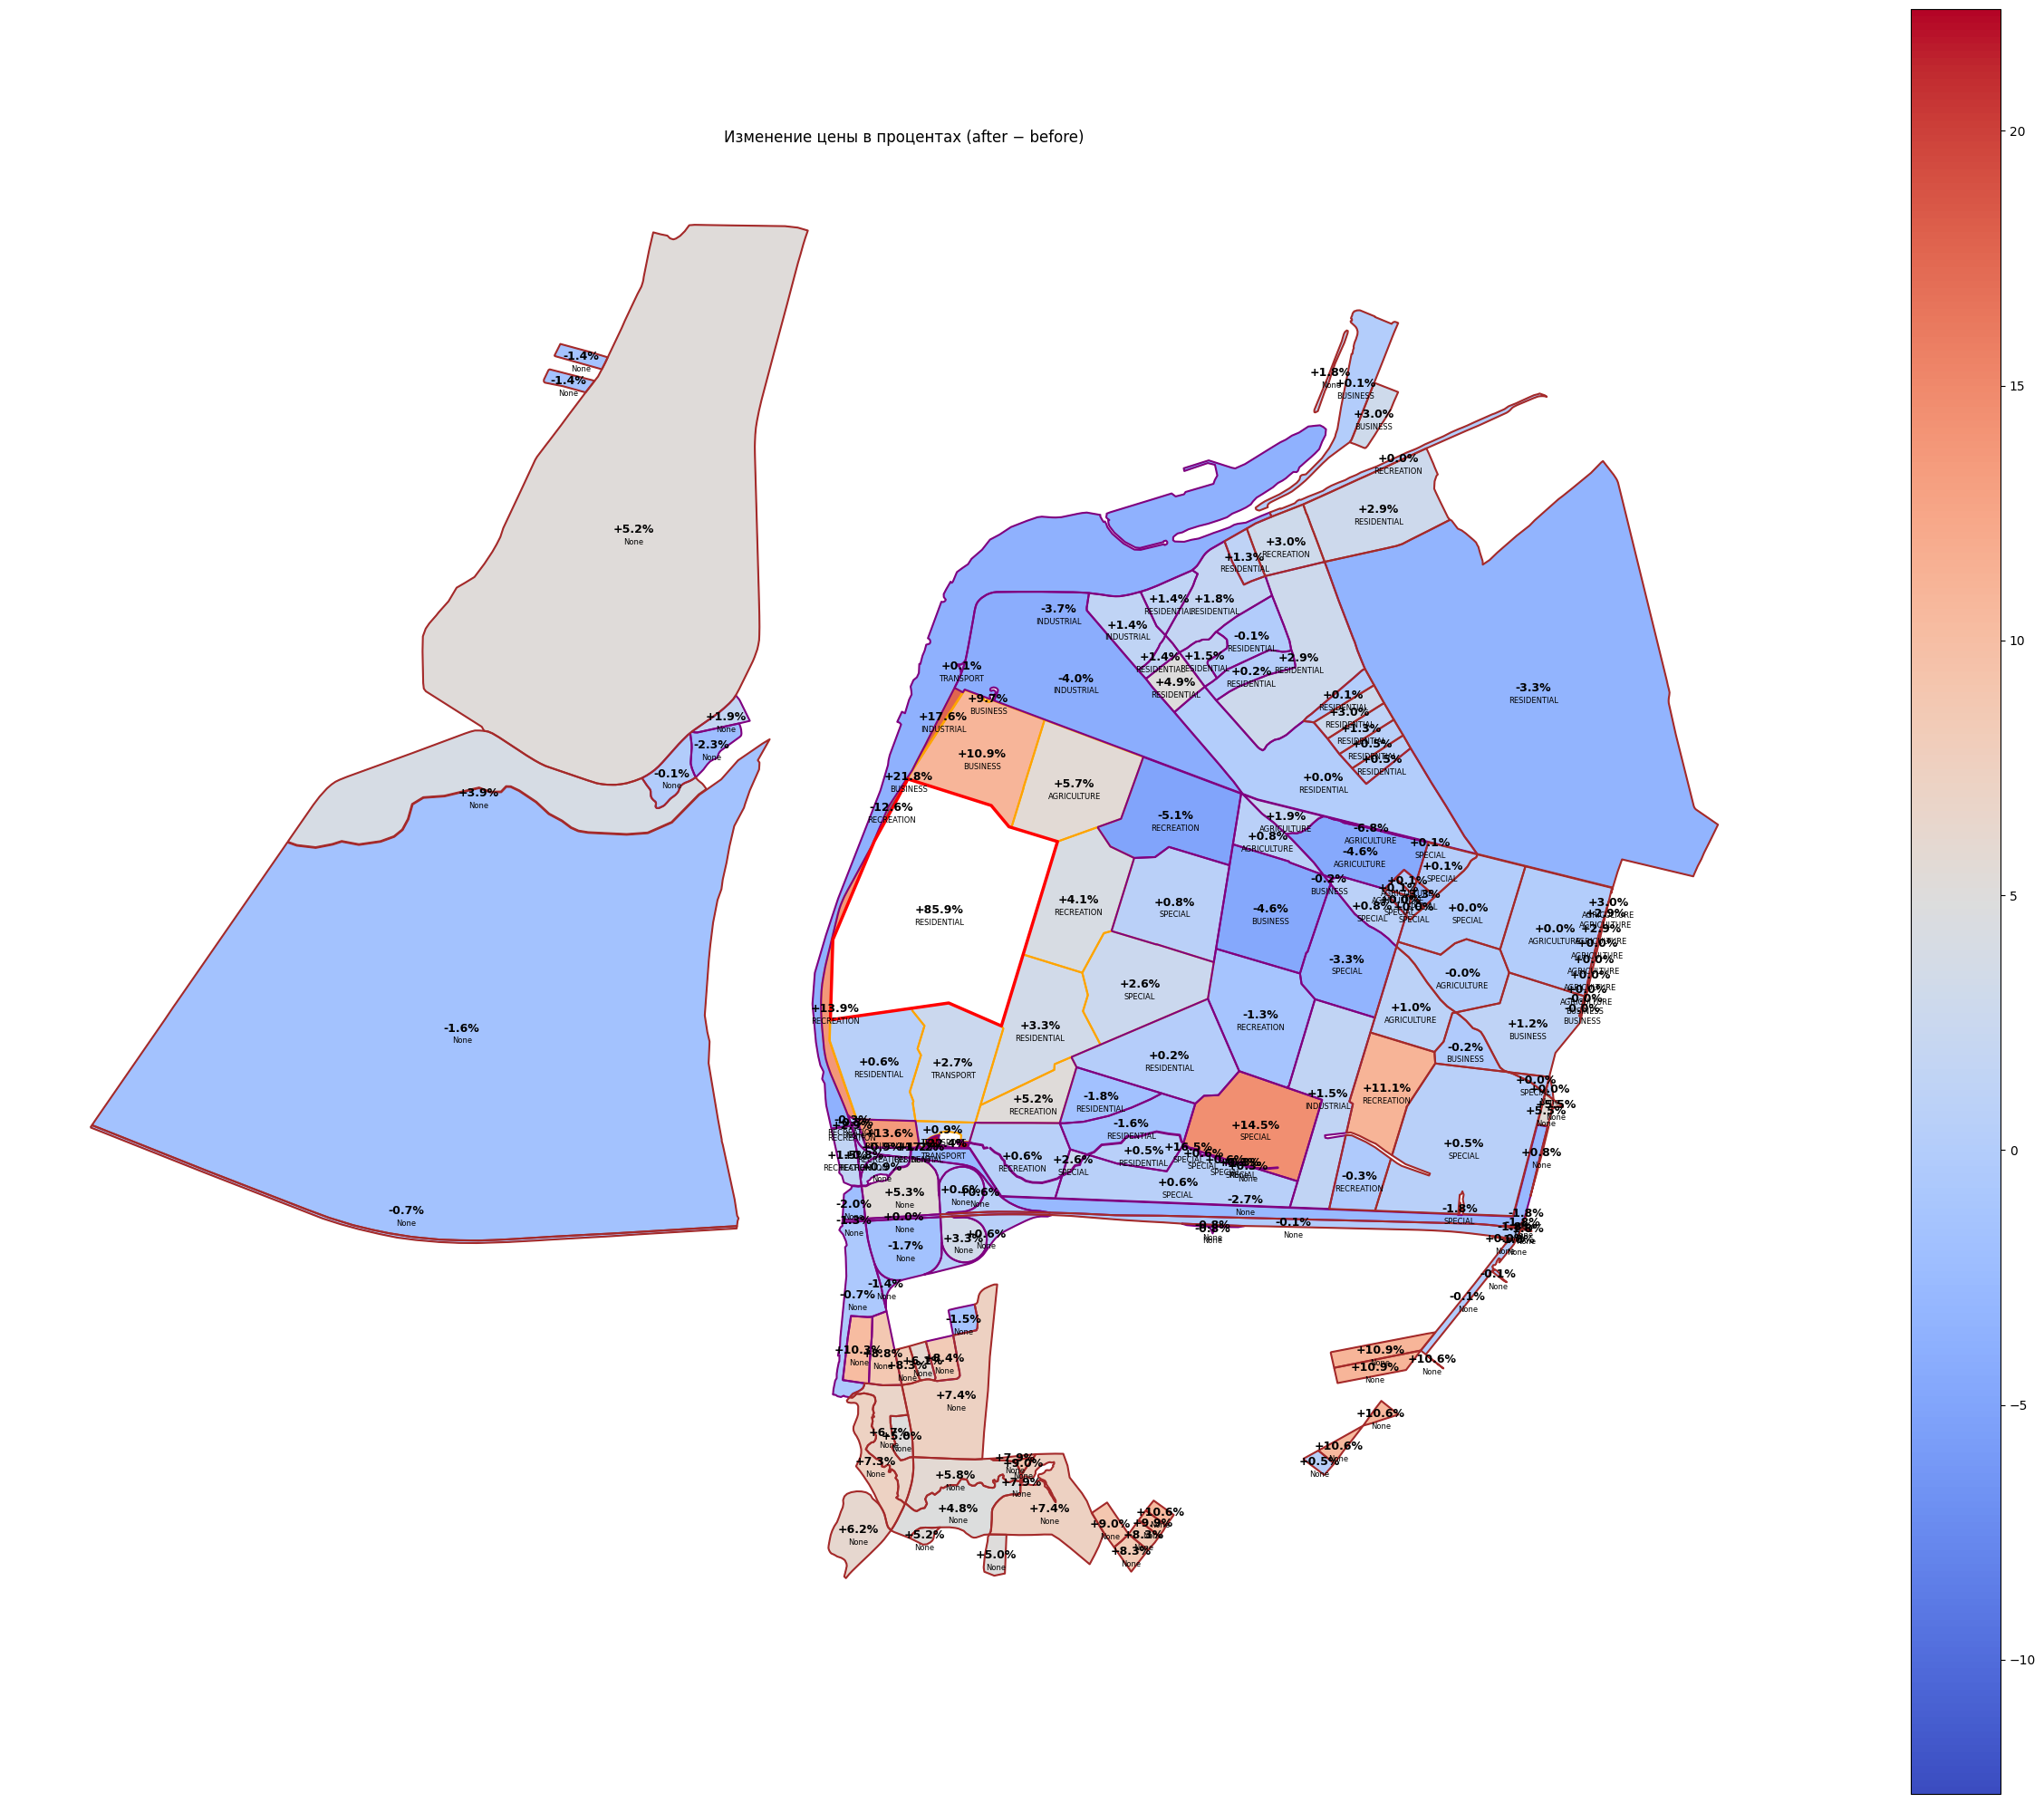

In [ ]:
# ------------ 0. Библиотеки и константы ------------
import pandas as pd
import numpy as np
import geopandas as gpd
from catboost import CatBoostRegressor
from libpysal.weights import DistanceBand, lag_spatial
import matplotlib.pyplot as plt

# Список исходных фичей
orig_feats = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility'
]
# Категориальные фичи
cat_feats = ['land_use', 'morphotype']
numeric_feats = [c for c in orig_feats if c not in cat_feats]

# Радиусы для матриц соседства
radius_list = [300, 500, 1000, 2000, 3000]

# ------------ 1. Загрузка данных и модели ------------
# Предполагается, что у вас уже загружен GeoDataFrame blocks, например:
# blocks = gpd.read_file('blocks.geojson')

model = CatBoostRegressor()
model.load_model('./data/model.cbm')

# ------------ 2. Построение матриц соседства ------------
w_radii = {}
for r in radius_list:
    w = DistanceBand.from_dataframe(
        blocks, threshold=r, binary=True, silence_warnings=True
    )
    w.transform = 'r'
    w_radii[r] = w


# 1) Применить сценарий к одному кварталу с автоматическим перерасчётом ТЭП
def apply_scenario(blocks, target_idx: int, changes: dict) -> pd.DataFrame:
    df = blocks.copy()
    row = df.loc[target_idx].to_dict()

    # --- обновляем базовые поля из changes ---
    row.update(changes)

    site_area = float(row['site_area'])

    # --- согласуем жил/нежил/общие площади ---
    # приоритет: заданные в changes -> вывод из пары -> вывод по mxi -> оставить как было
    build = float(row.get('build_floor_area', df.at[target_idx, 'build_floor_area']))
    live  = float(row.get('living_area',       df.at[target_idx, 'living_area']))
    non   = row.get('non_living_area', np.nan)

    if not np.isfinite(non):
        if 'build_floor_area' in changes and 'living_area' in changes:
            non = max(build - live, 0.0)
        elif ('mxi' in changes) or ('mxi' in row):
            mxi = float(row.get('mxi', df.at[target_idx, 'mxi']))
            non = max(mxi * build, 0.0)
        else:
            non = float(df.at[target_idx, 'non_living_area'])

    # если задали non_living_area и living_area, но не build — пересчитаем build
    if ('non_living_area' in changes and 'living_area' in changes) and ('build_floor_area' not in changes):
        build = live + non

    row['build_floor_area'] = build
    row['living_area']      = live
    row['non_living_area']  = non

    # --- плотностные и долевые показатели ---
    footprint = float(row.get('footprint_area', df.at[target_idx, 'footprint_area']))
    pop       = float(row.get('population',     df.at[target_idx, 'population']))

    row['fsi']  = build / site_area if site_area > 0 else np.nan
    row['gsi']  = footprint / site_area if site_area > 0 else np.nan
    row['mxi']  = (non / build) if build > 0 else 0.0
    row['l']    = (build / pop) if pop > 0 else np.nan
    row['osr']  = (site_area - footprint) / site_area if site_area > 0 else np.nan
    row['share_living']     = live / site_area if site_area > 0 else np.nan
    row['share_non_living'] = non / site_area if site_area > 0 else np.nan

    # --- land_use / share согласование (если нужно) ---
    if 'residential' in changes and 'share' not in changes:
        row['share'] = float(row['residential'])

    # записываем строку обратно
    for k, v in row.items():
        df.at[target_idx, k] = v

    return df


# 2) Плоттер, который принимает blocks_before и blocks_after (без параметра changes)
def plot_scenario_with_radii_from_blocks(
    blocks_before, blocks_after, w_radii, model,
    orig_feats, numeric_feats, target_idx
):
    from matplotlib.transforms import offset_copy
    radius_list = sorted(w_radii.keys())

    # соседи по кольцам
    radius_ids, prev = {}, set()
    for r in radius_list:
        ids = set(w_radii[r].neighbors.get(target_idx, [])) - prev
        radius_ids[r] = sorted(ids); prev |= ids
    idxs = [target_idx] + [i for r in radius_list for i in radius_ids[r]]
    neighbor_idxs = [i for i in idxs if i != target_idx]

    def add_lags(frame: pd.DataFrame) -> pd.DataFrame:
        f = frame.copy()
        gm = f[numeric_feats].mean()
        lag_cols = []
        for feat in numeric_feats:
            vec = f[feat].fillna(gm[feat])
            for r in radius_list:
                col = f'lag{r}_{feat}'
                f[col] = lag_spatial(w_radii[r], vec)
                lag_cols.append(col)
        for r in radius_list:
            ncol = f'n_neighbors_{r}'
            f[ncol] = pd.Series({i: len(nb) for i, nb in w_radii[r].neighbors.items()})
            lag_cols.append(ncol)
        return f, lag_cols

    # лаги и предсказания
    b_with_lags, lag_cols = add_lags(blocks_before)
    a_with_lags, _        = add_lags(blocks_after)

    all_feats = orig_feats + lag_cols
    Xb = b_with_lags.loc[idxs, all_feats].copy()
    Xa = a_with_lags.loc[idxs, all_feats].copy()

    for X in (Xb, Xa):
        X['land_use']   = X['land_use'].fillna('missing').astype('category')
        X['morphotype'] = X['morphotype'].fillna('missing').astype('category')

    preds_before = model.predict(Xb)
    preds_after  = model.predict(Xa)

    # gdf для отчёта
    gdf = a_with_lags.loc[idxs].copy()
    gdf['pred_before'] = preds_before
    gdf['pred_after']  = preds_after
    gdf['log_diff']    = gdf['pred_after'] - gdf['pred_before']
    gdf['pct_change']  = (np.exp(gdf['log_diff']) - 1) * 100

    def ntype(i):
        if i == target_idx: return 'target'
        for r in radius_list:
            if i in radius_ids[r]: return f'radius_{r}m'
        return 'other'

    print("Δ цены в процентах (после − до):")
    for i, row in gdf.iterrows():
        print(f" • {i} ({ntype(i)}): {row['pred_before']:.3f} → {row['pred_after']:.3f} "
              f"(Δ {row['log_diff']:+.3f} log, {row['pct_change']:+.1f}%)")

    print("\nСреднее изменение цены по радиусам:")
    for r in radius_list:
        ids = radius_ids[r]
        if ids:
            m = gdf.loc[ids, 'pct_change'].mean()
            s = gdf.loc[ids, 'pct_change'].std()
            print(f" • Радиус {r}м: среднее {m:+.1f}%, std {s:.1f}, участков {len(ids)}")
        else:
            print(f" • Радиус {r}м: нет соседей")

    all_neighbor_ids = [i for r in radius_list for i in radius_ids[r]]
    if all_neighbor_ids:
        overall_mean = gdf.loc[all_neighbor_ids, 'pct_change'].mean()
        overall_std  = gdf.loc[all_neighbor_ids, 'pct_change'].std()
        print(f"\nИтог по всем соседям: {overall_mean:+.1f}% (std {overall_std:.1f}%, n={len(all_neighbor_ids)})")
    else:
        print("\nНет соседей.")

    # Визуализация
    fig, ax = plt.subplots(figsize=(25, 20))
    vmin = gdf.loc[neighbor_idxs, 'pct_change'].min()
    vmax = gdf.loc[neighbor_idxs, 'pct_change'].max()
    gdf.loc[neighbor_idxs].plot(ax=ax, column='pct_change', cmap='coolwarm',
                                vmin=vmin, vmax=vmax, legend=True,
                                edgecolor='black', linewidth=0.5, zorder=1)

    for color, r in zip(['blue','green','orange','purple','brown'], radius_list):
        ids = radius_ids[r]
        if ids: gdf.loc[ids].boundary.plot(ax=ax, color=color, linewidth=1.5, zorder=2)

    gdf.loc[[target_idx]].boundary.plot(ax=ax, edgecolor='red', linewidth=2.5, zorder=3)

    # подписи: процент + тип землепользования ниже
    for i, row in gdf.iterrows():
        x, y = row.geometry.centroid.coords[0]
        ax.text(x, y, f"{row['pct_change']:+.1f}%", ha='center', va='center',
                fontsize=9, fontweight='bold', zorder=4)
        ax.text(x, y, str(row.get('land_use', 'missing')),
                ha='center', va='center', fontsize=6, zorder=4,
                transform=offset_copy(ax.transData, fig=fig, y=-10, units='points'))

    ax.axis('off'); ax.set_title('Изменение цены в процентах (after − before)', pad=12)
    plt.tight_layout(); plt.show()



# исходные blocks_cat
blocks_before = blocks

changes = {
    'land_use': 'RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
    # mxi/l/osr/share_living НЕ задаём — пересчитаются автоматически
}
#2630

target_idx = 62
blocks_after = apply_scenario(blocks_before, target_idx, changes)

plot_scenario_with_radii_from_blocks(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    w_radii=w_radii,
    model=model,
    orig_feats=orig_feats,
    numeric_feats=numeric_feats,
    target_idx=target_idx
)

## Собираем геодатафрейм


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from libpysal.weights import lag_spatial

# Предполагаем, что у вас уже есть:
# blocks, model, orig_feats, numeric_feats, radius_list, w_radii, target_idx, changes

# ——— 1) Построим лаг-признаки так же, как в функции ———
blocks_base = blocks.copy()
lag_cols = []
gm = blocks_base[numeric_feats].mean()

for feat in numeric_feats:
    vec = blocks_base[feat].fillna(gm[feat])
    for r in radius_list:
        col = f'lag{r}_{feat}'
        blocks_base[col] = lag_spatial(w_radii[r], vec)
        lag_cols.append(col)
for r in radius_list:
    ncol = f'n_neighbors_{r}'
    blocks_base[ncol] = pd.Series({i: len(nb) for i, nb in w_radii[r].neighbors.items()})
    lag_cols.append(ncol)

all_feats = orig_feats + lag_cols

# ——— 2) Определим idxs, как в вашей функции ———
radius_ids = {}
prev = set()
for r in radius_list:
    ids = set(w_radii[r].neighbors.get(target_idx, [])) - prev
    radius_ids[r] = sorted(ids)
    prev |= ids

idxs = [target_idx] + [i for r in radius_list for i in radius_ids[r]]

# ——— 3) Предсказания до изменений ———
Xb = blocks_base.loc[idxs, all_feats].copy()
Xb['land_use']   = Xb['land_use'].fillna('missing').astype('category')
Xb['morphotype'] = Xb['morphotype'].fillna('missing').astype('category')
preds_before    = model.predict(Xb)

# ——— 4) Вносим изменения и пересчитываем лаги ———
blocks_scn = blocks_base.copy()
for feat, val in changes.items():
    blocks_scn.at[target_idx, feat] = val

for feat in numeric_feats:
    vec = blocks_scn[feat].fillna(gm[feat])
    for r in radius_list:
        col = f'lag{r}_{feat}'
        blocks_scn[col] = lag_spatial(w_radii[r], vec)

Xa = blocks_scn.loc[idxs, all_feats].copy()
Xa['land_use']   = Xa['land_use'].fillna('missing').astype('category')
Xa['morphotype'] = Xa['morphotype'].fillna('missing').astype('category')
preds_after     = model.predict(Xa)

# ——— 5) Собираем единый GeoDataFrame ———
gdf = blocks_scn.loc[idxs].copy()
gdf['pred_log_before'] = preds_before
gdf['pred_price_before'] = np.exp(preds_before)
gdf['pred_log_after']  = preds_after
gdf['pred_price_after'] = np.exp(preds_after)

# (по желанию можно добавить log_diff и pct_change)
gdf['log_diff']   = gdf['pred_log_after'] - gdf['pred_log_before']
gdf['pct_change'] = (np.exp(gdf['log_diff']) - 1) * 100

# # ——— 6) Сохраняем в один GeoJSON ———
# gdf.to_file('predictions_before_after.geojson', driver='GeoJSON')


/home/mvin/prostor-examples/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/home/mvin/prostor-examples/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/home/mvin/prostor-examples/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

In [ ]:
def total_price_change(gdf):
    """
    Предполагается, что pred_price_before и pred_price_after уже в рублях (всего по кварталу).
    Возвращает суммарную цену до/после и как она изменилась.
    """
    df = gdf[['pred_price_before', 'pred_price_after']].copy()
    df = df.dropna(subset=['pred_price_before', 'pred_price_after'], how='any')
    
    total_before = df['pred_price_before'].sum()
    total_after = df['pred_price_after'].sum()
    
    if total_before == 0:
        raise ValueError("Суммарная предсказанная цена до равна нулю, деление невозможно.")
    
    abs_change = total_after - total_before  # в рублях
    factor = total_after / total_before      # во сколько раз
    percent_change = (abs_change / total_before) * 100  # в процентах

    return {
        'total_before': total_before,
        'total_after': total_after,
        'absolute_change_rub': abs_change,
        'factor_change': factor,
        'percent_change': percent_change,
    }

# Пример использования:
result = total_price_change(gdf)  # если ваш GeoDataFrame называется gdf

print(f"Суммарно до: {result['total_before']:,.0f} ₽")
print(f"Суммарно после: {result['total_after']:,.0f} ₽")
print(f"Абсолютное изменение: {result['absolute_change_rub']:,.0f} ₽")
print(f"Фактор изменения: {result['factor_change']:.4f}x")
print(f"Процентное изменение: {result['percent_change']:.2f}%")


Суммарно до: 17,997,279,776 ₽
Суммарно после: 18,216,559,220 ₽
Абсолютное изменение: 219,279,445 ₽
Фактор изменения: 1.0122x
Процентное изменение: 1.22%


In [ ]:
from dataclasses import dataclass

@dataclass
class SERParams:
    investment_per_capita_0: float
    grp_per_capita_0: float
    budget_revenue_0: float
    avg_wage_0: float
    wear_of_fixed_assets_0: float

    epsilon_inv: float = 1.0
    kappa_tf: float = 0.5
    epsilon_grp_A: float = 1.0
    labor_share: float = 0.6
    tax_rate_income: float = 0.13
    tax_rate_property: float = 0.01
    tax_rate_other: float = 0.1
    wage_to_income_multiplier: float = 1.0
    share_investment_on_renewal: float = 0.3
    elasticity_wage_vs_grp: float = 1.0

def simulate_ser_chain(params: SERParams, land_price_factor: float, population: float):
    delta_p = land_price_factor - 1

    investment_pc = params.investment_per_capita_0 * (1 + params.epsilon_inv * delta_p)

    inv_growth = ((investment_pc - params.investment_per_capita_0)
                  / params.investment_per_capita_0) if params.investment_per_capita_0 else 0
    A_factor = 1 + params.kappa_tf * inv_growth

    grp_pc = params.grp_per_capita_0 * (1 + params.epsilon_grp_A * (A_factor - 1))

    wage = params.avg_wage_0 * (1 + params.elasticity_wage_vs_grp * ((grp_pc / params.grp_per_capita_0) - 1))

    total_wage_mass = wage * population
    income_tax = params.tax_rate_income * total_wage_mass * params.wage_to_income_multiplier

    property_tax = params.tax_rate_property * (land_price_factor * params.wear_of_fixed_assets_0 * 1_000)

    other_tax = params.tax_rate_other * (grp_pc * population)

    budget = income_tax + property_tax + other_tax

    renewal_investment_factor = 1 + inv_growth
    wear = params.wear_of_fixed_assets_0 * (1 / renewal_investment_factor) * (1 - params.share_investment_on_renewal * inv_growth)

    return {
        'investment_per_capita': {'before': params.investment_per_capita_0, 'after': investment_pc},
        'grp_per_capita': {'before': params.grp_per_capita_0, 'after': grp_pc},
        'avg_wage': {'before': params.avg_wage_0, 'after': wage},
        'budget_revenue': {'before': params.budget_revenue_0, 'after': budget},
        'wear_of_fixed_assets': {'before': params.wear_of_fixed_assets_0, 'after': wear},
        'intermediate': {
            'TFP_factor': A_factor,
            'income_tax': income_tax,
            'property_tax': property_tax,
            'other_tax': other_tax,
        },
        'land_price_factor': land_price_factor,
    }

# ====== Пример вызова ======
baseline_params = SERParams(
    investment_per_capita_0=50000,      # руб. на человека
    grp_per_capita_0=800000,            # руб.
    budget_revenue_0=1_000_000_000,     # руб.
    avg_wage_0=60000,                   # руб.
    wear_of_fixed_assets_0=25000,       # тыс. руб.
)

land_price_factor = 1.3  # цена земли выросла на 30%
population = 1_000_000   # численность

result = simulate_ser_chain(baseline_params, land_price_factor, population)

# Печать с процентными изменениями
for key in ['investment_per_capita', 'grp_per_capita', 'avg_wage', 'budget_revenue', 'wear_of_fixed_assets']:
    before = result[key]['before']
    after = result[key]['after']
    pct = (after / before - 1) * 100 if before else float('nan')
    print(f"{key}: до={before:,.2f}, после={after:,.2f}, изменение={pct:.2f}%")

print("\nПромежуточные:")
for k, v in result['intermediate'].items():
    print(f"  {k}: {v:,.2f}")




investment_per_capita: до=50,000.00, после=65,000.00, изменение=30.00%
grp_per_capita: до=800,000.00, после=920,000.00, изменение=15.00%
avg_wage: до=60,000.00, после=69,000.00, изменение=15.00%
budget_revenue: до=1,000,000,000.00, после=100,970,325,000.00, изменение=9997.03%
wear_of_fixed_assets: до=25,000.00, после=17,500.00, изменение=-30.00%

Промежуточные:
  TFP_factor: 1.15
  income_tax: 8,970,000,000.00
  property_tax: 325,000.00
  other_tax: 92,000,000,000.00
